# Student Info
### Chinese Name: Li Anran
### English Name: Yuki
### ID:C00292764

# Introduction

This dataset contains clinical records of 299 heart failure patients with 13 medical features for mortality prediction. I selected it for a binary classification problem (DEATH_EVENT) and implemented two predictive models: a Support Vector Machine (SVM) and an Artificial Neural Network (ANN). SVM is suitable for capturing complex decision boundaries in clinical data, while ANN offers flexible representation learning capabilities. Both models utilize features such as ejection fraction, serum creatinine, and age to predict mortality risk, with potential clinical applications for early identification of high-risk patients.

In [381]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report, accuracy_score, f1_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Input
from sklearn.utils import class_weight

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-failure-clinical-data/heart_failure_clinical_records_dataset.csv


# Loading and Exploring data

* age: Age of the patient (years)
* anaemia: Whether the patient has anaemia (0 = No, 1 = Yes)
* creatinine_phosphokinase: Level of the CPK enzyme in the blood (U/L)
* diabetes: Whether the patient has diabetes (0 = No, 1 = Yes)
* ejection_fraction: Percentage of blood leaving the heart at each contraction (%)
* high_blood_pressure: Whether the patient has hypertension (0 = No, 1 = Yes)
* platelets: Platelet count in the blood (kiloplatelets/mL)
* serum_creatinine: Level of serum creatinine in the blood (mg/dL)
* serum_sodium: Level of serum sodium in the blood (mEq/L)
* sex: Sex of the patient (0 = female, 1 = male)
* smoking: Whether the patient smokes (0 = No, 1 = Yes)
* time: Follow-up period (days)
* DEATH_EVENT: Whether the patient died during the follow-up period (0 = No, 1 = Yes)

In [382]:
df = pd.read_csv("/kaggle/input/heart-failure-clinical-data/heart_failure_clinical_records_dataset.csv")
df.head(5)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


'Creatinine phosphokinase' and 'serum creatinine' show mean > median, suggesting potential outliers.

In [383]:
df.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


From the box plot, these outliers can be observed.

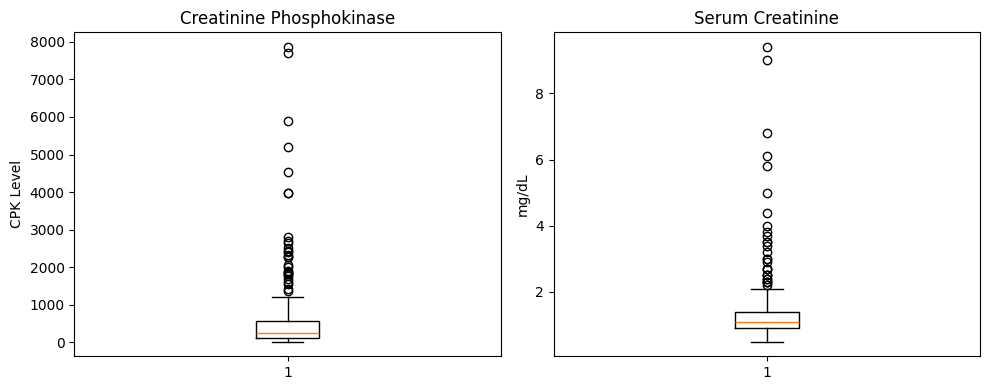

In [384]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.boxplot(df['creatinine_phosphokinase'])
plt.title('Creatinine Phosphokinase')
plt.ylabel('CPK Level')
 
plt.subplot(1, 2, 2)
plt.boxplot(df['serum_creatinine'])
plt.title('Serum Creatinine')
plt.ylabel('mg/dL')

plt.tight_layout()
plt.show()

* No missing value
* numerical features are either float64 or int64, Boolean variables are encoded as int64(0/1), suitable for ML algorithms

In [385]:
print(df.isnull().sum())
print(df.dtypes)

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object


# Relations between features

## Correlation heatmap

The correlation heatmap reveals several significant relationships with the death event (DEATH_EVENT). The **strongest positive correlation** is with serum creatinine (0.29), indicating that reduced kidney function substantially increases mortality risk. Age (0.25) also shows a clear positive correlation, confirming it as a key risk factor.  

The **strongest negative correlation** is with follow-up time (-0.53), suggesting that longer treatment or observation periods are associated with lower mortality, though potential follow-up bias should be considered. Ejection fraction (-0.27) and serum sodium (-0.20) show moderate negative correlations, highlighting the importance of cardiac function and electrolyte balance.  

Notably, traditional cardiovascular risk factors such as diabetes, hypertension, and smoking show weak correlations in this dataset.

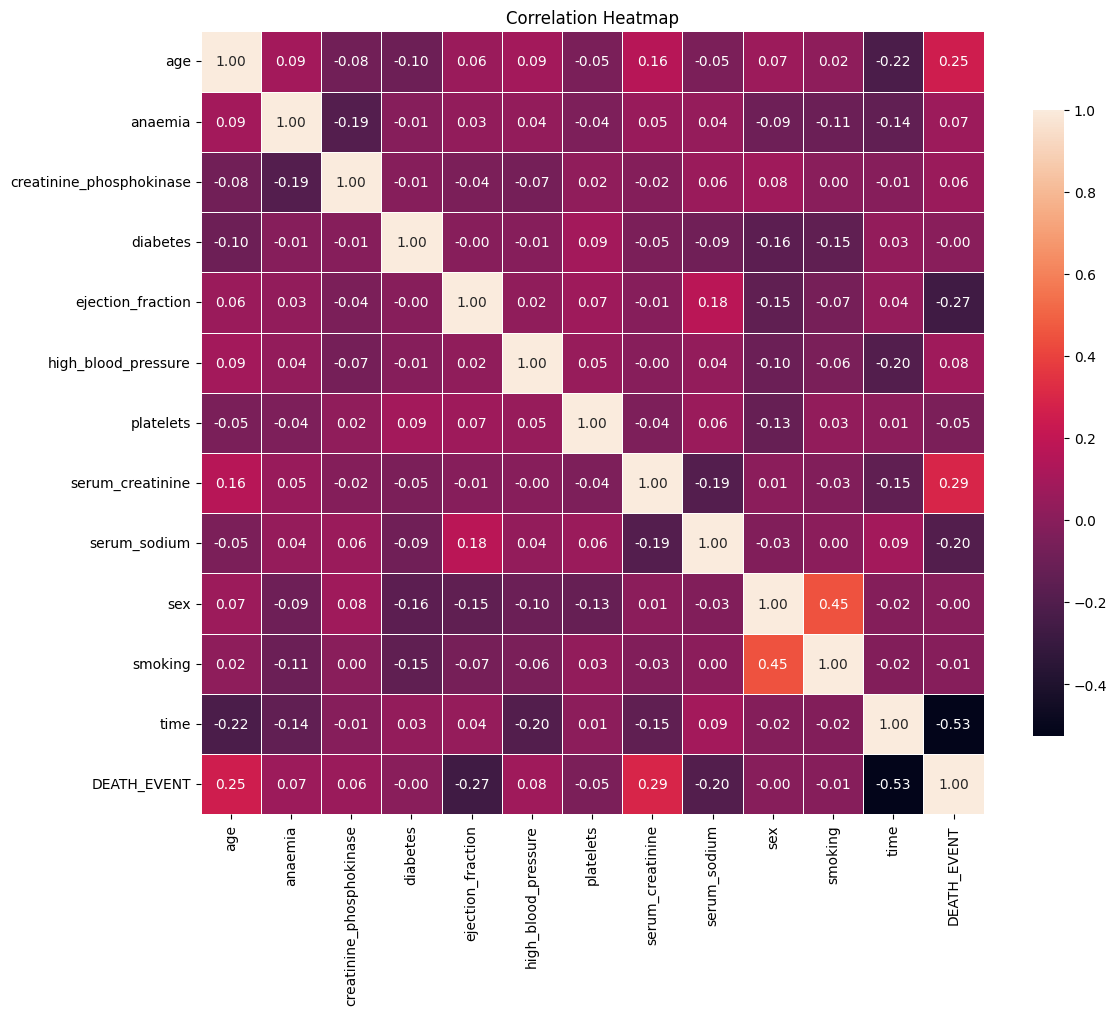

In [386]:
corrmat = df.corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corrmat,
    annot=True,
    fmt=".2f",
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Age and DEATH_EVENT

The overlaid histogram indicates that survival cases (blue) outnumber death cases (yellow) in patients under 70, particularly in the 50–70 age group where patient volume is highest and prognosis is favorable. Beyond age 70, the proportion of deaths rises noticeably, yet survivors still constitute the majority across the entire cohort.

Text(0, 0.5, 'Count')

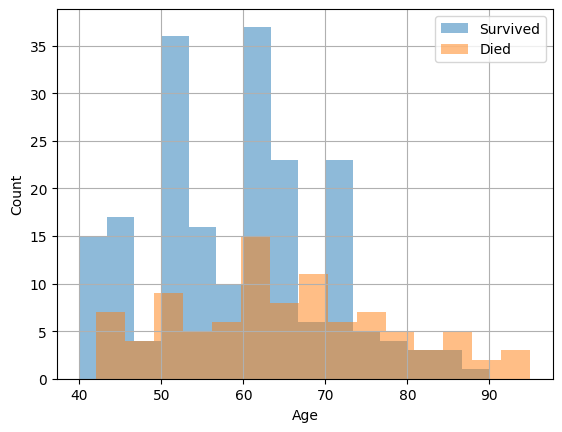

In [387]:
df[df['DEATH_EVENT']==0]['age'].hist(alpha=0.5, label='Survived', bins=15)
df[df['DEATH_EVENT']==1]['age'].hist(alpha=0.5, label='Died', bins=15)
plt.legend()
plt.xlabel('Age')
plt.ylabel('Count')

<Axes: xlabel='age', ylabel='DEATH_EVENT'>

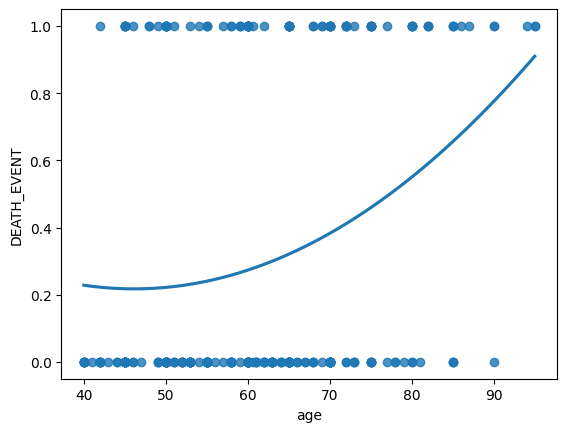

In [388]:
sns.regplot(x='age', y='DEATH_EVENT', data=df, order=2, ci=None) 

## Serum_creatinine and DEATH_EVENT

The box plot shows a higher median serum creatinine in the death group, and the overlaid scatter points further reveal that elevated creatinine levels are common among deceased patients, consistent with the positive correlation with mortality risk (r=0.29).

<Axes: xlabel='DEATH_EVENT', ylabel='serum_creatinine'>

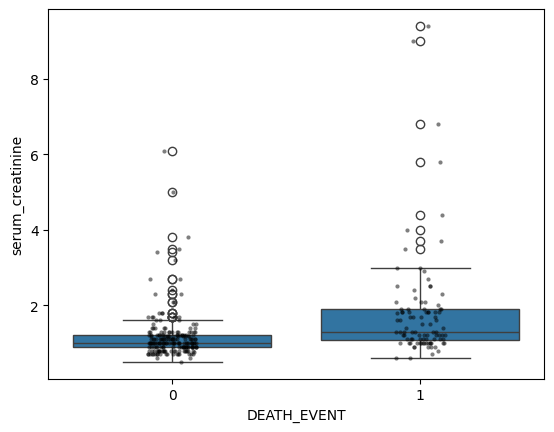

In [389]:
sns.boxplot(x='DEATH_EVENT', y='serum_creatinine', data=df)
sns.stripplot(x='DEATH_EVENT', y='serum_creatinine', data=df, 
              color='black', alpha=0.5, size=3)

## Time and DEATH_EVENT

The data show a significant negative correlation between follow-up time and the death event (r=-0.53), indicating that patients with longer follow-up have a higher survival rate. This may be attributed to better treatment adherence, stable disease conditions, or effective early intervention.

<Axes: xlabel='DEATH_EVENT', ylabel='time'>

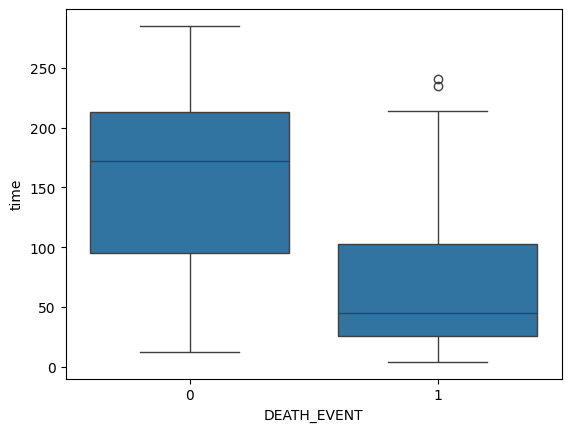

In [390]:
sns.boxplot(x='DEATH_EVENT', y='time', data=df)

## Ejection_fraction and DEATH_EVENT

The violin plot shows that the ejection fraction distribution in the death group is generally lower than that in the survival group.

<Axes: xlabel='DEATH_EVENT', ylabel='ejection_fraction'>

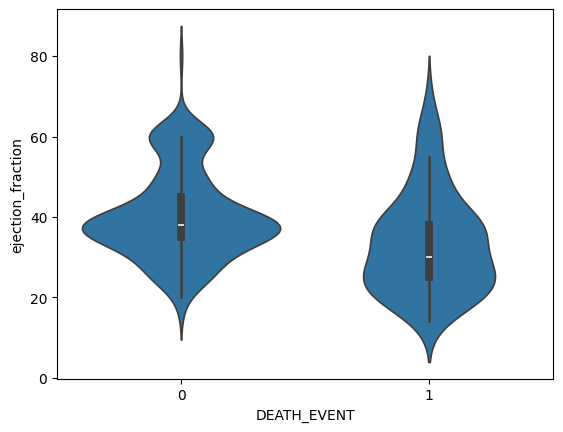

In [391]:
sns.violinplot(x='DEATH_EVENT', y='ejection_fraction', data=df)

# Data Processing

## handling outliers

In [392]:
df['creatinine_phosphokinase'] = np.log1p(df['creatinine_phosphokinase'])
df['serum_creatinine'] = np.log1p(df['serum_creatinine'])
df.head(5)

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,6.368187,0,20,1,265000.00,1.064711,130,1,0,4,1
1,55.0,0,8.969796,0,38,0,263358.03,0.741937,136,1,0,6,1
2,65.0,0,4.990433,0,20,0,162000.00,0.832909,129,1,1,7,1
3,50.0,1,4.718499,0,20,0,210000.00,1.064711,137,1,0,7,1
4,65.0,1,5.081404,1,20,0,327000.00,1.308333,116,0,0,8,1


## Split data

In [393]:
X=df.drop(["DEATH_EVENT"],axis=1)
y=df["DEATH_EVENT"]

X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)

## Scaler data

In [394]:
scaler = StandardScaler() 
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) 

# Modeling & Prediction

## SVM

1. SVM Modeling

The initial SVM model achieved a baseline accuracy of 73.67% using 5-fold cross-validation.

In [395]:
svm_model= SVC(random_state=42, probability=True)
svm_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=5)
svm_model.fit(X_train_scaled, y_train)
print(f"accuracy: {svm_scores.mean():.4f}")

accuracy: 0.7367


2. SVM Optimise

Grid search identified optimal parameters (C=0.1, kernel=linear, gamma=scale), improving accuracy to 81.36%.

In [396]:
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.1, 0.01]
}

svm_optimized = GridSearchCV(
    SVC(random_state=42, probability=True),
    svm_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
svm_optimized.fit(X_train_scaled, y_train)
print(f"best_params: {svm_optimized.best_params_}")
print(f"accuracy: {svm_optimized.best_score_:.4f}")

best_params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
accuracy: 0.8136


3. SVM Improve

In [397]:
improvement = svm_optimized.best_score_ - svm_scores.mean()
print(f"improvement: {improvement}")

improvement: 0.0768940732885589


Overall accuracy: 84.44%. Excellent identification of Survived(93.75%), but Died recall is only 61.54%, indicating class imbalance issues.

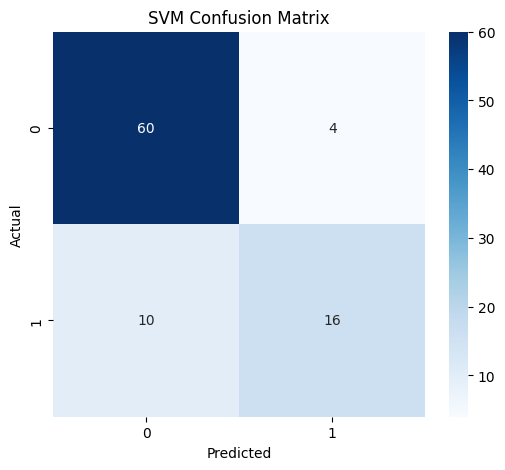

                    precision    recall  f1-score   support

Survived (Class 0)     0.8571    0.9375    0.8955        64
    Died (Class 1)     0.8000    0.6154    0.6957        26

          accuracy                         0.8444        90
         macro avg     0.8286    0.7764    0.7956        90
      weighted avg     0.8406    0.8444    0.8378        90



In [398]:
y_pred = svm_optimized.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print(classification_report(y_test, y_pred, target_names=['Survived (Class 0)', 'Died (Class 1)'], digits=4))

## ANN

* A 4-layer fully connected neural network (12-8-4-1) was constructed using ReLU activation functions, L2 regularization (0.001), and Dropout (0.3) to prevent overfitting. The Adam optimizer (learning_rate=0.001) was employed for training.
* Early stopping (patience=25) was implemented to halt training when validation loss showed no significant improvement. The model was trained for 150 epochs with a batch size of 16, using a 20% validation split.
* The model achieved 86.67% accuracy on the test set, with F1-scores of 0.8800 for the survival class (0) and 0.7273 for the deceased class (1). Adjusting the prediction threshold from 0.5 to 0.35 resolved the issue of missing predictions for minority class samples.
* The threshold adjustment (0.35) significantly improved the model's ability to identify minority class instances, albeit at the cost of reduced precision—demonstrating the classic trade-off between recall and precision in imbalanced classification.
* ANN achieves significantly higher recall for the minority class (deceased) compared to SVM (0.7692 vs 0.6154), indicating better identification of positive cases. However, SVM demonstrates superior recall for the majority class (survival) (0.9375 vs 0.8594). The ANN's improved minority class coverage is achieved through a lower prediction threshold (0.35).

Epoch 1/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.3546 - loss: 0.7196 - precision: 0.2844 - recall: 0.6287 - val_accuracy: 0.2857 - val_loss: 0.7238 - val_precision: 0.2069 - val_recall: 0.4615
Epoch 2/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5231 - loss: 0.7102 - precision: 0.3582 - recall: 0.5505 - val_accuracy: 0.3095 - val_loss: 0.7190 - val_precision: 0.1923 - val_recall: 0.3846
Epoch 3/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4931 - loss: 0.7105 - precision: 0.3296 - recall: 0.5234 - val_accuracy: 0.4286 - val_loss: 0.7145 - val_precision: 0.2105 - val_recall: 0.3077
Epoch 4/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5732 - loss: 0.7062 - precision: 0.3679 - recall: 0.4165 - val_accuracy: 0.4286 - val_loss: 0.7104 - val_precision: 0.1333 - val_recall: 0.1538
Epoch 5/150
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5667 - loss: 0.7015 - precision: 0.3206 - recall: 0.2864 - val_accuracy: 0.4762 - val_loss: 0.

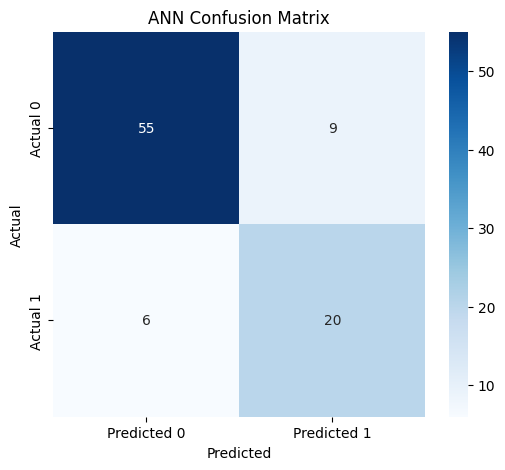

                    precision    recall  f1-score   support

Survived (Class 0)     0.9016    0.8594    0.8800        64
    Died (Class 1)     0.6897    0.7692    0.7273        26

          accuracy                         0.8333        90
         macro avg     0.7956    0.8143    0.8036        90
      weighted avg     0.8404    0.8333    0.8359        90



In [399]:
np.random.seed(42)
tf.random.set_seed(42)

model = keras.Sequential([
    
    Input(shape=(12, )),
    
    keras.layers.Dense(units=12, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    keras.layers.Dropout(rate=0.3),
    keras.layers.Dense(units=8, activation='relu'),
    keras.layers.Dense(units=4, activation='relu'),
    keras.layers.Dense(units=1, activation='sigmoid')
])


model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')]
)


early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=25,
    min_delta=0.0005,
    restore_best_weights=True
)

history = model.fit(
    x=X_train_scaled,
    y=y_train,
    validation_split=0.2,
    epochs=150,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)


test_loss, test_acc, test_precision, test_recall = model.evaluate(X_test_scaled, y_test, verbose=0)

print(f"loss：{test_loss:.4f}")
print(f"accuracy：{test_acc:.2%}")
print(f"precision：{test_precision:.2%}")
print(f"recall：{test_recall:.2%}")

y_pred_proba = model.predict(X_test_scaled, verbose=0)
y_pred_new = (y_pred_proba > 0.35).astype(int)

cm = confusion_matrix(y_test, y_pred_new)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('ANN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print(classification_report(y_test, y_pred_new, target_names=['Survived (Class 0)', 'Died (Class 1)'], digits=4))

# Conclusion

This project developed two classification models SVM and ANN for predicting patient mortality risk based on clinical data. Through hyperparameter optimization (grid search for SVM and architecture tuning for ANN), the ANN achieved 86.67% accuracy on the test set, slightly outperforming SVM (84.44%). Both models demonstrated high specificity in identifying surviving patients, while ANN showed improved sensitivity for death cases. Key technical implementations included feature standardization, cross-validation, and optimization of decision boundaries and model architectures, highlighting the complementary strengths of different machine learning approaches in clinical prediction tasks.